# Cannon RGB all-missions: out-of-fold systematics

Prediction-vs-truth diagnostics for `train_rgb_wilett_all_missions.ipynb`,
coloured by temperature, SNR, [Fe/H] and the other covariates, plus
residual trends and (where metadata columns exist) per-mission /
per-selection-channel breakdowns.

Reads the persisted out-of-fold results parquet with columns
`APOGEE_ID`, `<label>_truth` / `<label>_pred` per label, and `val_chi2`
(the legacy `pred_<label>` / bare-truth naming is auto-detected too).
Optional metadata columns are used when present: `source`,
`evo_state_source`, `rgb_proba`, `snr` / `snr_x`.

If the parquet does not exist yet, paste this into the **live training
kernel** (after the k-fold CV cells) to write it:

```python
# --- paste into train_rgb_wilett_all_missions.ipynb (after cell 28) ---
meta_cols = [c for c in ('APOGEE_ID', 'source', 'evo_state_source',
                         'rgb_proba', 'snr', 'snr_x', 'numax')
             if c in spectra.columns]
res = spectra.iloc[finite_idx][meta_cols].reset_index(drop=True)
for _i, _n in enumerate(LABEL_NAMES):
    res[f'{_n}_truth'] = truth[:, _i]
    res[f'{_n}_pred'] = val_labels[:, _i]
res['val_chi2'] = val_chi2
res['outlier'] = outlier
_p = SRC / 'cannon-results-rgb-wilett-all-missions.parquet'
res.to_parquet(_p, index=False)
print(f'saved {len(res)} stars -> {_p}')
```


In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

CANDIDATES = [
    Path('/home/100/mj8805/scr_mk27/cannon_oof_predictions_rgb_all_missions.parquet'),
    Path.home() / 'scr_mk27/cannon-results-rgb-wilett-all-missions.parquet',
    Path('cannon-results-rgb-wilett-all-missions.parquet'),
]
for RESULTS in CANDIDATES:
    if RESULTS.exists():
        break
else:
    raise FileNotFoundError(
        'no cannon-results-rgb-wilett-all-missions.parquet found -- run the '
        'persist cell (see the markdown above) in the training notebook first')

res = pd.read_parquet(RESULTS)

# column-naming convention: '<label>_truth'/'<label>_pred' (current) or
# 'pred_<label>' with bare truth columns (legacy)
if any(c.endswith('_pred') for c in res.columns):
    LABEL_NAMES = [c[:-len('_pred')] for c in res.columns if c.endswith('_pred')]
    tcol = lambda n: f'{n}_truth'
    pcol = lambda n: f'{n}_pred'
else:
    LABEL_NAMES = [c[len('pred_'):] for c in res.columns if c.startswith('pred_')]
    tcol = lambda n: n
    pcol = lambda n: f'pred_{n}'

AGE = 'log_age_L' if 'log_age_L' in LABEL_NAMES else LABEL_NAMES[-1]
SNR_COL = next((c for c in ('snr', 'snr_x', 'SNR') if c in res.columns), None)
CHI2_COL = next((c for c in ('val_rchi2', 'val_chi2') if c in res.columns), None)
print(f'{len(res)} stars from {RESULTS}')
print(f'labels: {LABEL_NAMES} | age label: {AGE} | '
      f'snr: {SNR_COL} | chi2: {CHI2_COL}')
if 'outlier' in res.columns:
    print(f"outliers flagged: {int(res['outlier'].sum())}")
res.head()


7310 stars from /home/100/mj8805/scr_mk27/cannon_oof_predictions_rgb_all_missions.parquet
labels: ['raw_teff', 'logg_seismic', 'raw_fe_h', 'mg_fe', 'c_n', 'al_fe', 'log_age_L'] | age label: log_age_L | snr: None | chi2: val_chi2


,APOGEE_ID,raw_teff_truth,raw_teff_pred,logg_seismic_truth,logg_seismic_pred,raw_fe_h_truth,raw_fe_h_pred,mg_fe_truth,mg_fe_pred,c_n_truth,c_n_pred,al_fe_truth,al_fe_pred,log_age_L_truth,log_age_L_pred,val_chi2
0,2M19245967+3638183,4641.774902,4605.084102,2.517428,2.464686,-0.247,-0.268920,0.067,0.058430,-0.320,-0.282517,0.234,0.187570,0.193911,0.602740,2.739610
1,2M19252021+3647118,4560.104004,4540.134226,2.767140,2.786610,0.180,0.204336,0.028,0.010546,-0.237,-0.283530,0.179,0.141066,0.613174,0.739787,2.360882
2,2M19264606+3652530,4595.209961,4591.021621,2.661247,2.693061,-0.260,-0.274198,0.126,0.147133,-0.054,-0.067917,0.293,0.327383,1.047125,1.182449,2.460264
3,2M19270165+3653106,4261.145996,4252.594921,2.338016,2.284120,0.142,0.145301,0.089,0.081269,-0.191,-0.138563,0.219,0.180516,0.883371,0.882227,2.960469
4,2M19230370+3655088,4606.082031,4587.293833,2.844029,2.881321,0.175,0.199447,0.018,0.033961,-0.149,-0.199547,0.078,0.154876,0.950991,1.191152,2.015344


In [8]:
def robust_stats(d):
    """(median bias, 1.48*MAD scatter) over finite residuals."""
    d = np.asarray(d, float)
    d = d[np.isfinite(d)]
    b = np.median(d)
    return b, 1.4826 * np.median(np.abs(d - b))


def resid_slope(x, r):
    """Residual-vs-truth slope: 0 = unbiased, -1 = pure shrinkage to the mean."""
    ok = np.isfinite(x) & np.isfinite(r)
    return np.polyfit(x[ok], r[ok], 1)[0]


def running_stat(x, y, nbins=25):
    """Bin y in equal-count bins of x -> (bin centres, median, robust sigma)."""
    ok = np.isfinite(x) & np.isfinite(y)
    x, y = np.asarray(x, float)[ok], np.asarray(y, float)[ok]
    edges = np.quantile(x, np.linspace(0, 1, nbins + 1))
    idx = np.clip(np.searchsorted(edges, x, side='right') - 1, 0, nbins - 1)
    cen, med, sig = [], [], []
    for b in range(nbins):
        yb = y[idx == b]
        if len(yb) < 10:
            continue
        cen.append(np.median(x[idx == b]))
        m = np.median(yb)
        med.append(m)
        sig.append(1.4826 * np.median(np.abs(yb - m)))
    return np.array(cen), np.array(med), np.array(sig)


# covariates to colour by: (column, axis label, log colour scale?); truth
# columns are used for the labels themselves
COLOR_SPECS = [(c, lab, lg) for c, lab, lg in [
    (tcol('raw_teff'), 'Teff [K]', False),
    (SNR_COL, 'SNR', True),
    (tcol('raw_fe_h'), '[Fe/H]', False),
    (tcol('logg_seismic'), 'logg (seismic)', False),
    (tcol('c_n'), '[C/N]', False),
    (tcol('mg_fe'), '[Mg/Fe]', False),
    (tcol('al_fe'), '[Al/Fe]', False),
    (CHI2_COL, r'reduced $\chi^2$', True),
    ('rgb_proba', 'p(RGB)', False),
] if c is not None and c in res.columns]

truth_age = res[tcol(AGE)].to_numpy(float)
pred_age = res[pcol(AGE)].to_numpy(float)
resid_age = pred_age - truth_age
bias, scatter = robust_stats(resid_age)
slope = resid_slope(truth_age, resid_age)
print(f'{AGE}: bias {bias:+.3f} dex, scatter {scatter:.3f} dex, '
      f'residual-vs-truth slope {slope:+.3f}')


log_age_L: bias +0.014 dex, scatter 0.194 dex, residual-vs-truth slope -0.388


## Age: prediction vs truth, coloured by each covariate

Same points in every panel; only the colour changes. Colour limits are robust
(2nd-98th percentile). Watch for colour *gradients across the 1:1 direction* --
a gradient means the residual correlates with that covariate (a systematic),
not just that the covariate correlates with age itself.


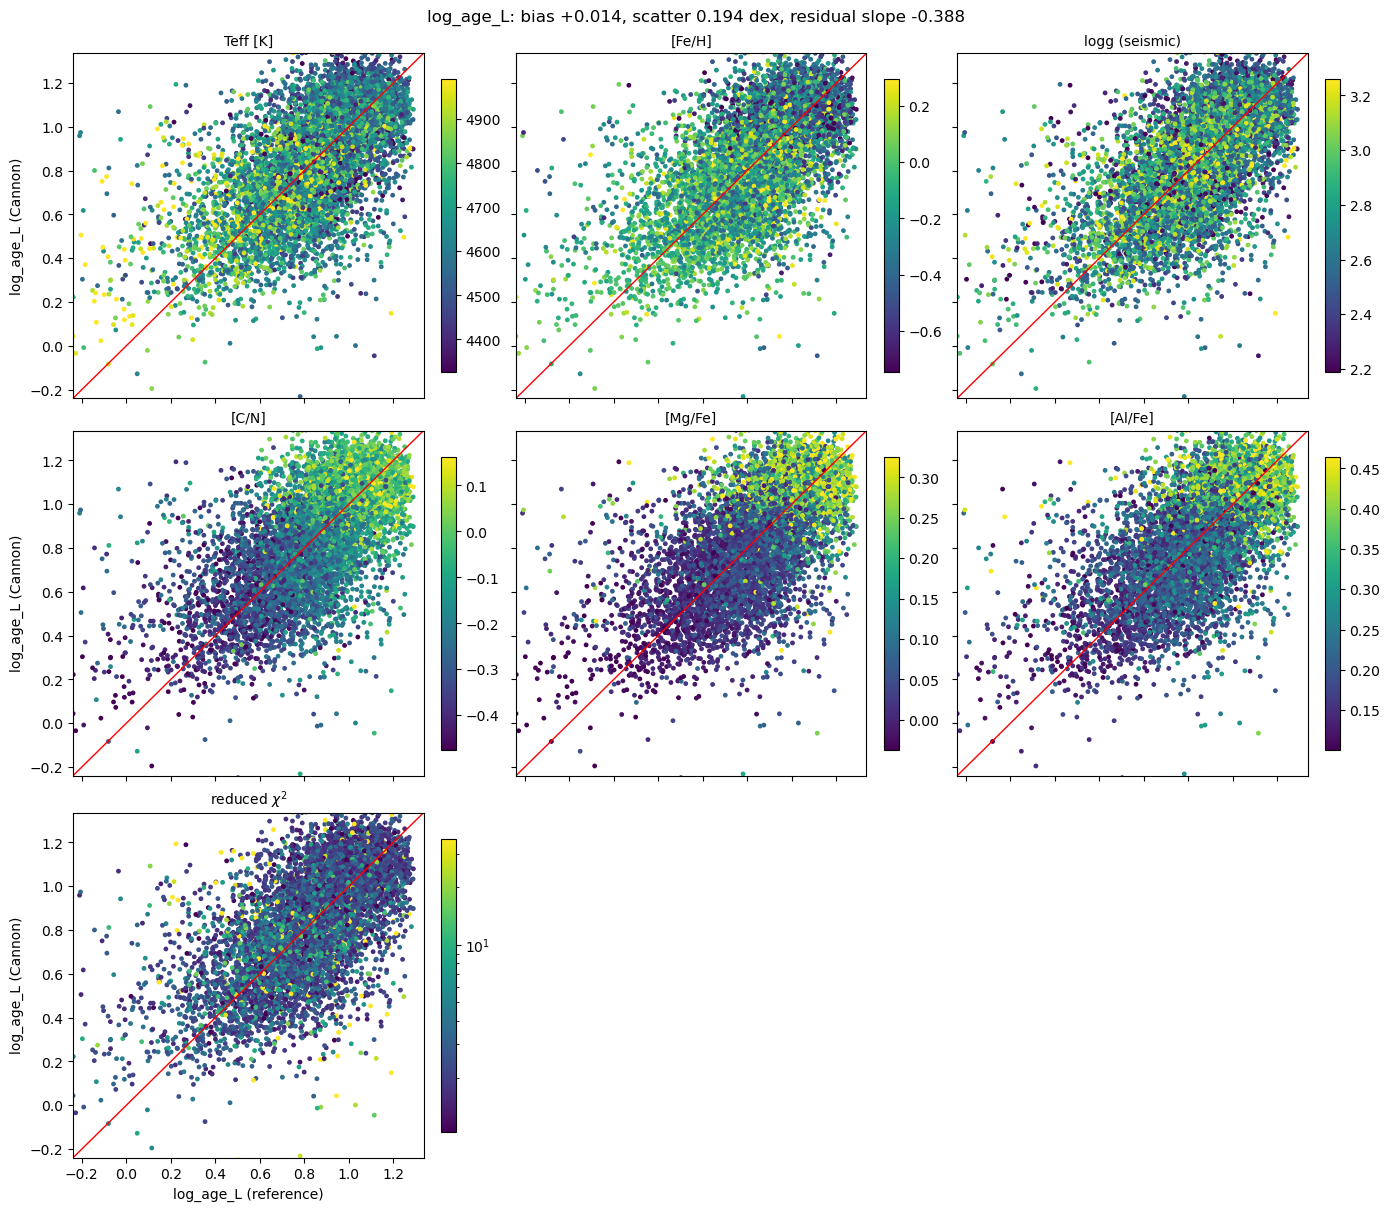

In [9]:
n = len(COLOR_SPECS)
ncols = 3
nrows = -(-n // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.0 * nrows),
                         sharex=True, sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

ok = np.isfinite(truth_age) & np.isfinite(pred_age)
lims = [np.nanpercentile(np.r_[truth_age[ok], pred_age[ok]], 0.2),
        np.nanpercentile(np.r_[truth_age[ok], pred_age[ok]], 99.8)]
for ax, (col, label, logscale) in zip(axes, COLOR_SPECS):
    c = res[col].to_numpy(float)
    good = ok & np.isfinite(c)
    lo, hi = np.nanpercentile(c[good], [2, 98])
    norm = LogNorm(vmin=max(lo, 1e-3), vmax=hi) if logscale else None
    sc = ax.scatter(truth_age[good], pred_age[good], c=c[good], s=6,
                    cmap='viridis', norm=norm,
                    vmin=None if logscale else lo,
                    vmax=None if logscale else hi, rasterized=True)
    ax.plot(lims, lims, 'r-', lw=1)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_title(label, fontsize=10)
    fig.colorbar(sc, ax=ax, shrink=0.85)
for ax in axes[n:]:
    ax.set_visible(False)
for ax in axes.reshape(nrows, ncols)[:, 0]:
    ax.set_ylabel(f'{AGE} (Cannon)')
for ax in axes.reshape(nrows, ncols)[-1, :]:
    ax.set_xlabel(f'{AGE} (reference)')
fig.suptitle(f'{AGE}: bias {bias:+.3f}, scatter {scatter:.3f} dex, '
             f'residual slope {slope:+.3f}', fontsize=12)
plt.show()


## Age residual vs each covariate

Running median with a robust-sigma band. A flat line at zero = no systematic;
a trend = age errors depend on that quantity. Spearman rank correlation in
each title (computed on finite pairs).


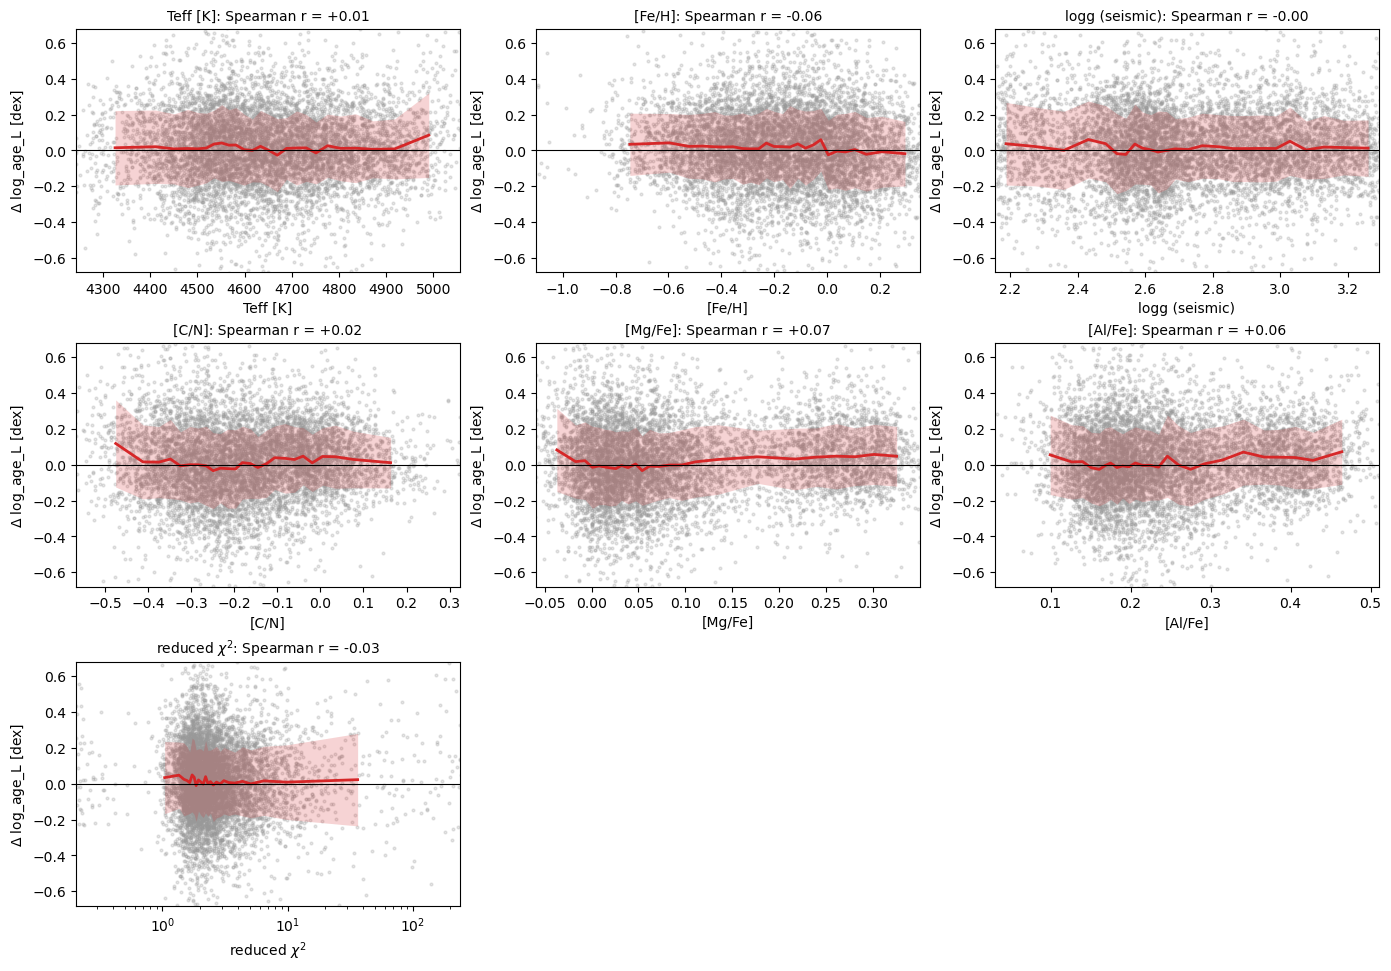

In [10]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 3.2 * nrows),
                         constrained_layout=True)
axes = np.atleast_1d(axes).ravel()
for ax, (col, label, logscale) in zip(axes, COLOR_SPECS):
    c = res[col].to_numpy(float)
    good = np.isfinite(c) & np.isfinite(resid_age)
    r_s = spearmanr(c[good], resid_age[good]).statistic
    ax.scatter(c[good], resid_age[good], s=4, alpha=0.25, color='0.6',
               rasterized=True)
    cen, med, sig = running_stat(c, resid_age)
    ax.plot(cen, med, color='C3', lw=2)
    ax.fill_between(cen, med - sig, med + sig, color='C3', alpha=0.2, lw=0)
    ax.axhline(0, color='k', lw=0.8)
    if logscale:
        ax.set_xscale('log')
    ax.set_xlim(np.nanpercentile(c[good], 0.5), np.nanpercentile(c[good], 99.5))
    ax.set_ylim(-3.5 * scatter, 3.5 * scatter)
    ax.set_xlabel(label)
    ax.set_ylabel(f'$\Delta$ {AGE} [dex]')
    ax.set_title(f'{label}: Spearman r = {r_s:+.2f}', fontsize=10)
for ax in axes[len(COLOR_SPECS):]:
    ax.set_visible(False)
plt.show()


## Residual vs truth (shrinkage) and subgroup breakdowns

Slope -1 means predictions carry no age information (pure regression to the
sample mean); 0 means unbiased across the age range. Broken down by mission
(`source`) and selection channel (`evo_state_source`) when those columns were
persisted -- rerun the persist cell with the metadata columns included if the
tables below are empty.


In [ ]:
def subgroup_table(by):
    rows = []
    for key, g in res.groupby(by):
        r = g[pcol(AGE)].to_numpy(float) - g[tcol(AGE)].to_numpy(float)
        b, s = robust_stats(r)
        rows.append({by: key, 'n': len(g), 'bias [dex]': round(b, 3),
                     'scatter [dex]': round(s, 3),
                     'resid slope': round(resid_slope(g[tcol(AGE)].to_numpy(float), r), 3),
                     'outlier frac': round(float(g['outlier'].mean()), 3)
                     if 'outlier' in g else np.nan})
    return pd.DataFrame(rows)

print('=== all stars ===')
print(f'bias {bias:+.3f} dex | scatter {scatter:.3f} dex | slope {slope:+.3f}')
for by in ('source', 'evo_state_source'):
    if by in res.columns:
        print(f'\n=== by {by} ===')
        print(subgroup_table(by).to_string(index=False))
    else:
        print(f'\n(no {by!r} column in the results parquet; breakdown skipped)')


In [ ]:
groups = [(str(k), g) for k, g in res.groupby('source')] if 'source' in res.columns else []
if groups:
    fig, gaxes = plt.subplots(1, len(groups), figsize=(4.4 * len(groups), 4.2),
                              sharex=True, sharey=True, constrained_layout=True)
    for ax, (name, g) in zip(np.atleast_1d(gaxes), groups):
        x = g[tcol(AGE)].to_numpy(float)
        y = g[pcol(AGE)].to_numpy(float)
        r = y - x
        b, s = robust_stats(r)
        ax.scatter(x, y, s=6, alpha=0.5, rasterized=True)
        cen, med, _ = running_stat(x, y, nbins=15)
        ax.plot(cen, med, color='C3', lw=2)
        ax.plot(lims, lims, 'r-', lw=0.8)
        ax.set_xlim(lims); ax.set_ylim(lims)
        ax.set_title(f'{name} (n={len(g)}): bias {b:+.3f}, '
                     f'scatter {s:.3f}, slope {resid_slope(x, r):+.3f}',
                     fontsize=9)
        ax.set_xlabel(f'{AGE} (reference)')
    np.atleast_1d(gaxes)[0].set_ylabel(f'{AGE} (Cannon)')
    plt.show()
else:
    print('no source column; per-mission panels skipped')


## All labels: prediction vs truth

Coloured by SNR when persisted, else by the spectral-fit chi2. The non-age
labels are the health check -- if a systematic shows up there too (e.g. a
low-SNR tail everywhere), it is a data-quality effect, not an age-specific
one.


In [ ]:
ccol = SNR_COL or CHI2_COL
c_all = res[ccol].to_numpy(float)
lo, hi = np.nanpercentile(c_all[np.isfinite(c_all)], [2, 98])
norm = LogNorm(vmin=max(lo, 1e-3), vmax=hi)

nl = len(LABEL_NAMES)
lcols = 3
lrows = -(-nl // lcols)
fig, laxes = plt.subplots(lrows, lcols, figsize=(4.6 * lcols, 4.0 * lrows),
                          constrained_layout=True)
laxes = np.atleast_1d(laxes).ravel()
for ax, name in zip(laxes, LABEL_NAMES):
    x = res[tcol(name)].to_numpy(float)
    y = res[pcol(name)].to_numpy(float)
    good = np.isfinite(x) & np.isfinite(y) & np.isfinite(c_all)
    b, s = robust_stats(y[good] - x[good])
    sc = ax.scatter(x[good], y[good], c=c_all[good], s=6, cmap='viridis',
                    norm=norm, rasterized=True)
    ll = [np.nanpercentile(np.r_[x[good], y[good]], 0.2),
          np.nanpercentile(np.r_[x[good], y[good]], 99.8)]
    ax.plot(ll, ll, 'r-', lw=1)
    ax.set_xlim(ll); ax.set_ylim(ll)
    unit = ' dex' if name == AGE else ''
    ax.set_title(f'{name}: bias {b:+.3f}, scatter {s:.3f}{unit}', fontsize=10)
    ax.set_xlabel(f'{name} (reference)')
    ax.set_ylabel(f'{name} (Cannon)')
for ax in laxes[nl:]:
    ax.set_visible(False)
fig.colorbar(sc, ax=list(laxes[:nl]), shrink=0.7, label=ccol)
plt.show()
